# 24069723 — MSc Data Science Project  
## Electricity Consumption Forecasting Using Classical and Machine Learning Time Series Models

**Student:** Sai Mahesh Battula  
**Course:** MSc Data Science Project  
**Dataset:** UCI Individual Household Electric Power Consumption Dataset  
**Target Variable:** `Global_active_power`

### Notebook Purpose
This notebook presents the full end-to-end workflow for the project, including data loading, preprocessing, exploratory data analysis, feature engineering, forecasting model development, evaluation, and interpretation of results.


## 1. Import required libraries
## Notebook Styling and Plot Configuration

The visualisations below use a consistent plotting theme to improve readability, interpretability, and presentation quality. A shared colour palette and helper styling settings are defined once and then reused across the notebook.

In [63]:
# Global plotting style
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["legend.fontsize"] = 11
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10

COLORS = {
    "primary": "#1f77b4",
    "secondary": "#ff7f0e",
    "accent": "#2ca02c",
    "danger": "#d62728",
    "purple": "#9467bd",
    "brown": "#8c564b",
    "grey": "#7f7f7f"
}

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime

In [2]:
# Mount the google drive to access the data zip file.
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# locating the zip file and accessing it.

import os

zip_path = "/content/drive/MyDrive/individual+household+electric+power+consumption.zip"

# Check if file exists
os.path.exists(zip_path)


True

In [4]:
# Import data

import zipfile

extract_path = "/content/individual+household+electric+power+consumption.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

os.listdir(extract_path)


['household_power_consumption.txt']

In [5]:

data_path = extract_path + "/household_power_consumption.txt"

df = pd.read_csv(
    data_path,
    sep=';',
    na_values='?',
    low_memory=False
)

df.head()


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [6]:
df.shape

(2075259, 9)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 9 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Date                   object 
 1   Time                   object 
 2   Global_active_power    float64
 3   Global_reactive_power  float64
 4   Voltage                float64
 5   Global_intensity       float64
 6   Sub_metering_1         float64
 7   Sub_metering_2         float64
 8   Sub_metering_3         float64
dtypes: float64(7), object(2)
memory usage: 142.5+ MB


## 2. Create DateTime index + sort + basic checks

In [8]:
# Combine Date + Time into a single datetime
df["DateTime"] = pd.to_datetime(
    df["Date"] + " " + df["Time"],
    format="%d/%m/%Y %H:%M:%S",
    errors="coerce"
)

In [9]:
# Drop old cols and set index
df = df.drop(columns=["Date", "Time"]).set_index("DateTime")

In [10]:
# Sort index (important for time-series)
df = df.sort_index()

In [11]:
# Quick checks
print("Datetime NA:", df.index.isna().sum())
print("Start:", df.index.min(), "End:", df.index.max())
print("Duplicates:", df.index.duplicated().sum())
df.head()

Datetime NA: 0
Start: 2006-12-16 17:24:00 End: 2010-11-26 21:02:00
Duplicates: 0


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
DateTime,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


## 3. Missing values overview

In [12]:
na_counts = df.isna().sum().sort_values(ascending=False)
na_pct = (df.isna().mean() * 100).sort_values(ascending=False)

missing_summary = pd.DataFrame({"missing_count": na_counts, "missing_pct": na_pct})
missing_summary


,missing_count,missing_pct
Global_active_power,25979,1.251844
Global_reactive_power,25979,1.251844
Voltage,25979,1.251844
Global_intensity,25979,1.251844
Sub_metering_1,25979,1.251844
Sub_metering_2,25979,1.251844
Sub_metering_3,25979,1.251844


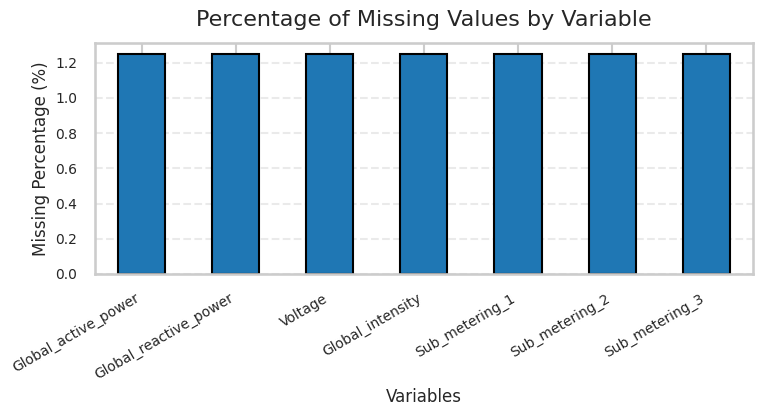

In [64]:
# Plot analysis of missing values
fig, ax = plt.subplots(figsize=(8, 4.5))
missing_summary["missing_pct"].plot(
    kind="bar",
    color=COLORS["primary"],
    edgecolor="black",
    ax=ax
)
ax.set_title("Percentage of Missing Values by Variable", pad=12)
ax.set_ylabel("Missing Percentage (%)")
ax.set_xlabel("Variables")
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


“Approximately 1.25% of observations contained missing values, occurring simultaneously across all sensor variables. This pattern suggests brief interruptions in data acquisition rather than variable-specific errors. Missing values were handled using time-based interpolation, followed by forward and backward filling at dataset boundaries. This approach preserves temporal continuity and avoids distortion of seasonal consumption patterns.”

In [14]:
# Time-based interpolation
df_interp = df.interpolate(method="time")

# Handle edge cases
df_interp = df_interp.ffill().bfill()

# Final check
df_interp.isna().sum()

,0
Global_active_power,0
Global_reactive_power,0
Voltage,0
Global_intensity,0
Sub_metering_1,0
Sub_metering_2,0
Sub_metering_3,0


📌 This preserves:

Temporal continuity

Seasonal patterns

Physical meaning of power signals

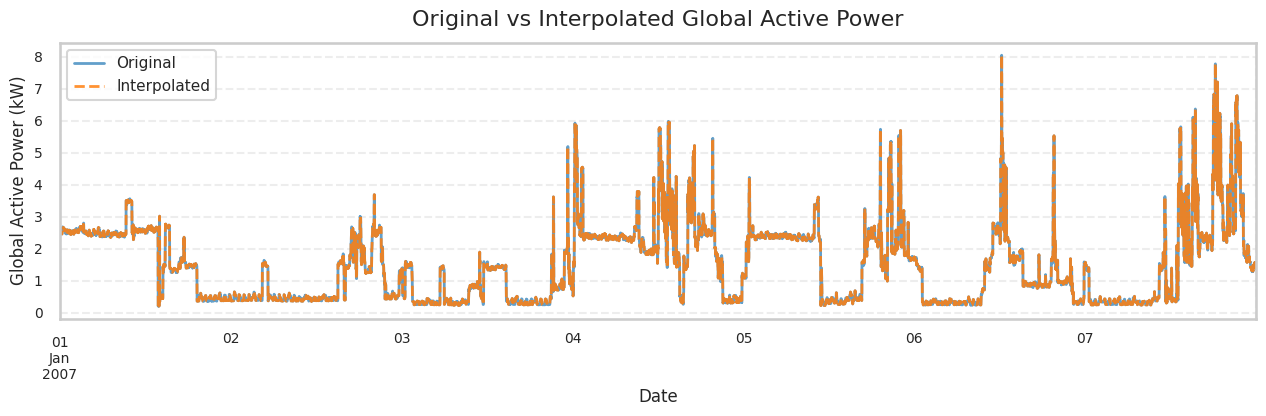

In [66]:
# Compare original vs interpolated for a small window
sample_start = "2007-01-01"
sample_end = "2007-01-07"

fig, ax = plt.subplots(figsize=(13, 4.5))
df.loc[sample_start:sample_end, "Global_active_power"].plot(
    label="Original",
    alpha=0.7,
    linewidth=2,
    color=COLORS["primary"],
    ax=ax
)
df_interp.loc[sample_start:sample_end, "Global_active_power"].plot(
    label="Interpolated",
    alpha=0.85,
    linewidth=2,
    linestyle="--",
    color=COLORS["secondary"],
    ax=ax
)
ax.set_title("Original vs Interpolated Global Active Power", pad=12)
ax.set_xlabel("Date")
ax.set_ylabel("Global Active Power (kW)")
ax.legend(frameon=True)
ax.grid(True, linestyle="--", alpha=0.35)
plt.tight_layout()
plt.show()

“A visual comparison between original and interpolated power consumption values over a representative time window confirmed that time-based interpolation preserved the temporal structure of the data. No artificial spikes or discontinuities were introduced, indicating that the interpolation strategy was appropriate for the observed missingness pattern.”

In [16]:
# Resample.

df_hourly = df_interp.resample("H").mean()
df_daily = df_interp.resample("D").mean()

df_hourly.shape, df_daily.shape


/tmp/ipykernel_10121/403729046.py:3: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_hourly = df_interp.resample("H").mean()


((34589, 7), (1442, 7))

In [17]:
# Base Dataset for Modelling.

df_model = df_interp.resample("H").mean()
df_model.head()

/tmp/ipykernel_10121/959382516.py:3: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_model = df_interp.resample("H").mean()


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
DateTime,,,,,,,
2006-12-16 17:00:00,4.222889,0.229000,234.643889,18.100000,0.0,0.527778,16.861111
2006-12-16 18:00:00,3.632200,0.080033,234.580167,15.600000,0.0,6.716667,16.866667
2006-12-16 19:00:00,3.400233,0.085233,233.232500,14.503333,0.0,1.433333,16.683333
2006-12-16 20:00:00,3.268567,0.075100,234.071500,13.916667,0.0,0.000000,16.783333
2006-12-16 21:00:00,3.056467,0.076667,237.158667,13.046667,0.0,0.416667,17.216667


## 4. Feature Engineering.

In [18]:
df_model["hour"] = df_model.index.hour
df_model["dayofweek"] = df_model.index.dayofweek
df_model["day"] = df_model.index.day
df_model["month"] = df_model.index.month
df_model["year"] = df_model.index.year
df_model["is_weekend"] = (df_model["dayofweek"] >= 5).astype(int)

In [19]:
df_model.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,hour,dayofweek,day,month,year,is_weekend
DateTime,,,,,,,,,,,,,
2006-12-16 17:00:00,4.222889,0.229000,234.643889,18.100000,0.0,0.527778,16.861111,17,5,16,12,2006,1
2006-12-16 18:00:00,3.632200,0.080033,234.580167,15.600000,0.0,6.716667,16.866667,18,5,16,12,2006,1
2006-12-16 19:00:00,3.400233,0.085233,233.232500,14.503333,0.0,1.433333,16.683333,19,5,16,12,2006,1
2006-12-16 20:00:00,3.268567,0.075100,234.071500,13.916667,0.0,0.000000,16.783333,20,5,16,12,2006,1
2006-12-16 21:00:00,3.056467,0.076667,237.158667,13.046667,0.0,0.416667,17.216667,21,5,16,12,2006,1


## 5. Lag Features (Critical for Forecasting)

In [20]:
# Target variable
target = "Global_active_power"

# Lag features (hours)
lags = [1, 2, 3, 6, 12, 24]

for lag in lags:
    df_model[f"{target}_lag_{lag}"] = df_model[target].shift(lag)

df_model.dropna(inplace=True)

## 6. Rolling Statistics (Captures Trend & Volatility)

In [21]:
windows = [3, 6, 12, 24]

for w in windows:
    # Use ONLY past values when predicting time t
    df_model[f"{target}_roll_mean_{w}"] = df_model[target].rolling(w).mean().shift(1)
    df_model[f"{target}_roll_std_{w}"]  = df_model[target].rolling(w).std().shift(1)

## 7. Drop Initial NaNs (From Lag/Rolling)

In [22]:
df_model.dropna(inplace=True)
df_model.shape

(34541, 27)

## 8. Exploratory Data Analysis (Final EDA)
(A) Distribution of Target

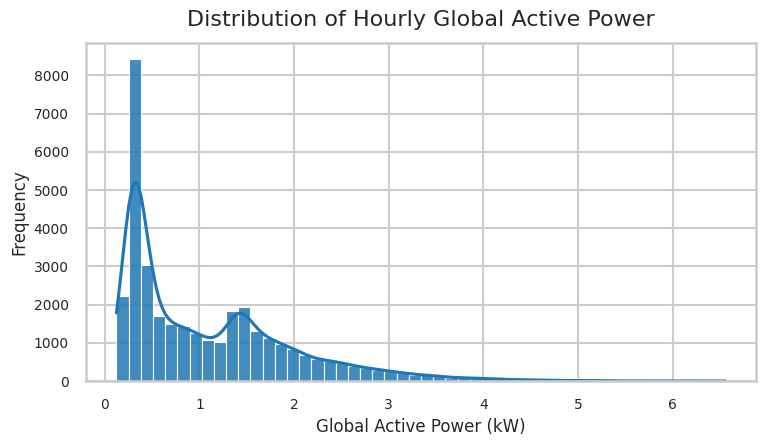

In [67]:
fig, ax = plt.subplots(figsize=(8, 4.8))
sns.histplot(
    df_model[target],
    bins=50,
    kde=True,
    color=COLORS["primary"],
    edgecolor="white",
    alpha=0.85,
    ax=ax
)
ax.set_title("Distribution of Hourly Global Active Power", pad=12)
ax.set_xlabel("Global Active Power (kW)")
ax.set_ylabel("Frequency")
plt.tight_layout()
plt.show()

(B) Correlation Heatmap (Numerical Only)

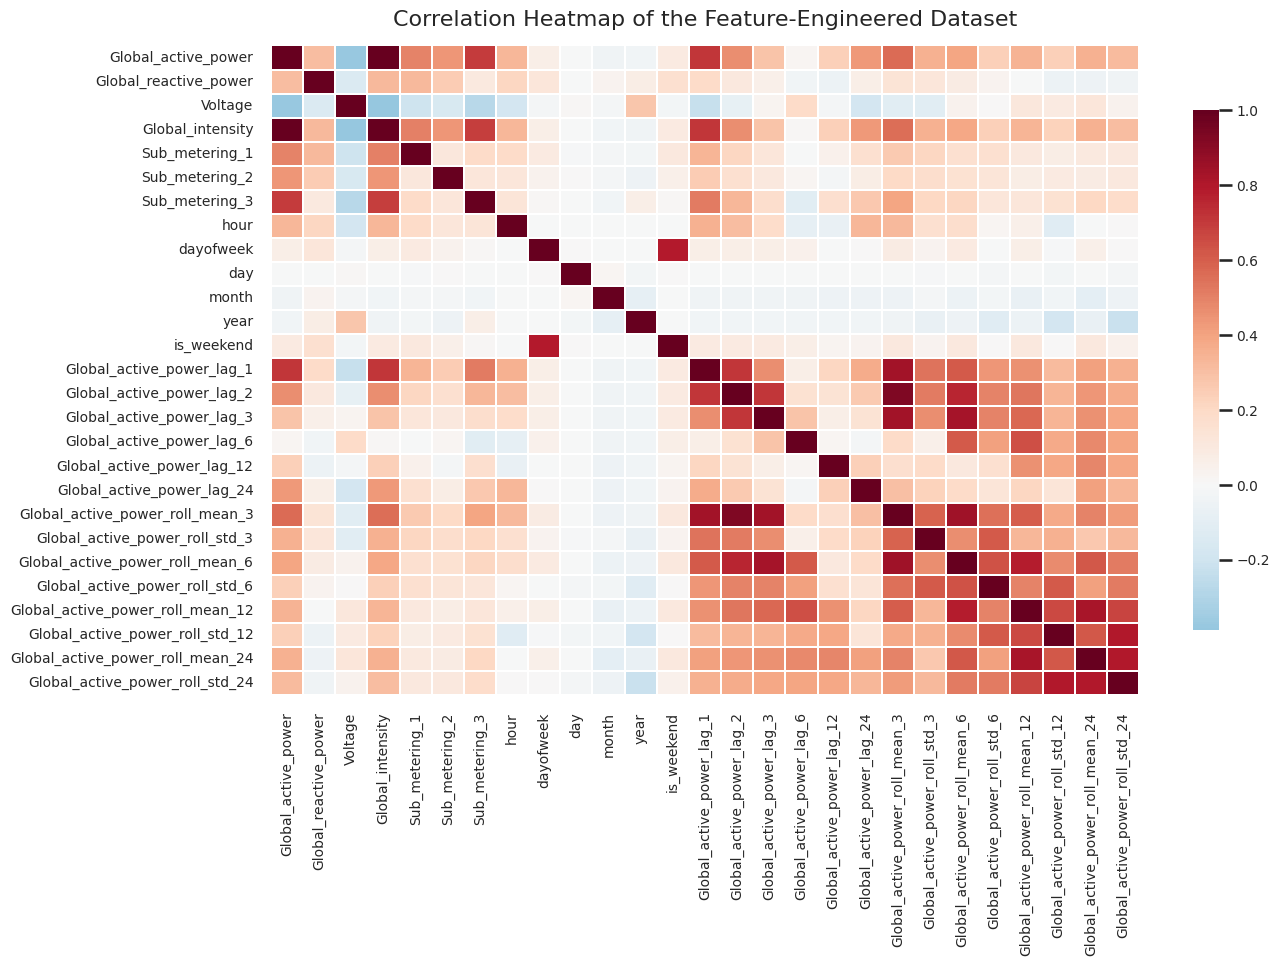

In [69]:
fig, ax = plt.subplots(figsize=(14, 10))
corr_matrix = df_model.corr(numeric_only=True)
sns.heatmap(
    corr_matrix,
    cmap="RdBu_r",
    center=0,
    linewidths=0.3,
    linecolor="white",
    cbar_kws={"shrink": 0.8},
    ax=ax
)
ax.set_title("Correlation Heatmap of the Feature-Engineered Dataset", pad=14)
plt.tight_layout()
plt.show()

(C) Focused Correlation with Target

In [25]:
corr_target = (
    df_model.corr()[target]
    .sort_values(ascending=False)
)

corr_target

,Global_active_power
Global_active_power,1.000000
Global_intensity,0.999418
Global_active_power_lag_1,0.714186
Sub_metering_3,0.696269
Global_active_power_roll_mean_3,0.563977
Sub_metering_1,0.496474
Global_active_power_lag_2,0.466869
Sub_metering_2,0.439619
Global_active_power_lag_24,0.435549
Global_active_power_roll_mean_6,0.388530


## 9. Multicollinearity Check

In [26]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = df_model.drop(columns=[target])
X = X.select_dtypes(include=[np.number])

vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

vif_data.sort_values("VIF", ascending=False)


/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,feature,VIF
12,Global_active_power_lag_1,inf
13,Global_active_power_lag_2,inf
18,Global_active_power_roll_mean_3,inf
14,Global_active_power_lag_3,inf
1,Voltage,8847.018365
10,year,8835.315301
20,Global_active_power_roll_mean_6,69.926171
22,Global_active_power_roll_mean_12,52.788221
24,Global_active_power_roll_mean_24,51.979509
25,Global_active_power_roll_std_24,42.038328


"Had a thought of Normalization. But, to avoid data leakage decided to apply scaling after train-test splitting to avoid data leakage."

## 10. Final “Modelling-Ready” Dataset

In [27]:
print("Final shape:", df_model.shape)
print("Missing values:", df_model.isna().sum().sum())
print("Datetime sorted:", df_model.index.is_monotonic_increasing)

Final shape: (34541, 27)
Missing values: 0
Datetime sorted: True



✅ No missing values

✅ Sorted datetime index

✅ Feature engineered

✅ EDA complete

| Stage             | Rows       | Why                   |
| ----------------- | ---------- | --------------------- |
| Raw data          | ~2,075,259 | Minute-level readings |
| Hourly resampled  | ~35,000    | 60 --> 1 aggregation  |
| After lag/rolling | 34,565     | Initial rows dropped  |

### Modelling Strategy

The modelling stage begins with a chronological train–test split to preserve temporal order and avoid data leakage.  
Three categories of models are then compared:

1. **Baseline models** — simple persistence-based references  
2. **Classical time-series models** — represented by SARIMA  
3. **Machine learning models** — using engineered lag, rolling, and calendar features


## 11. Train–Test Split (Chronological)

We will use 80% train, 20% test.

In [28]:
# Define target
target = "Global_active_power"

# Split index
train_size = int(len(df_model) * 0.8)

train = df_model.iloc[:train_size]
test = df_model.iloc[train_size:]

print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (27632, 27)
Test shape: (6909, 27)


The dataset was split chronologically to preserve temporal order and avoid data leakage.

## 12. Baseline Models.

12.1 **Naïve Forecast**

Prediction = previous value

In [29]:
naive_pred = test[target].shift(1)

# First value becomes NaN
naive_pred.iloc[0] = train[target].iloc[-1]

**12.2 Seasonal Naïve Forecast (Daily Seasonality)**

Since data is hourly, daily seasonality = 24 hours.

In [30]:
seasonal_lag = 24

seasonal_naive_pred = test[target].shift(seasonal_lag)

seasonal_naive_pred.iloc[:seasonal_lag] = train[target].iloc[-seasonal_lag:].values

**12.3 Evaluation Metrics**

We’ll use:

MAE

RMSE

SMAPE

In [31]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

def smape(y_true, y_pred):
    denom = (np.abs(y_true) + np.abs(y_pred)) / 2.0
    denom = np.where(denom == 0, 1e-8, denom)
    return np.mean(np.abs(y_true - y_pred) / denom) * 100

def evaluate(true, pred):
    mae = mean_absolute_error(true, pred)
    rmse = np.sqrt(mean_squared_error(true, pred))
    sm = smape(true, pred)
    return mae, rmse, sm

# Evaluate Naive
mae_n, rmse_n, smape_n = evaluate(test[target], naive_pred)

# Evaluate Seasonal Naive
mae_sn, rmse_sn, smape_sn = evaluate(test[target], seasonal_naive_pred)

print("Naive Forecast:")
print("MAE:", mae_n)
print("RMSE:", rmse_n)
print("sMAPE:", smape_n)

print("\nSeasonal Naive Forecast:")
print("MAE:", mae_sn)
print("RMSE:", rmse_sn)
print("sMAPE:", smape_sn)



Naive Forecast:
MAE: 0.3813064281330242
RMSE: 0.5898058697062362
sMAPE: 36.812806650290476

Seasonal Naive Forecast:
MAE: 0.5255106475699216
RMSE: 0.7780318888728245
sMAPE: 49.16509471593192


**12.4 Plot Baseline Predictions**

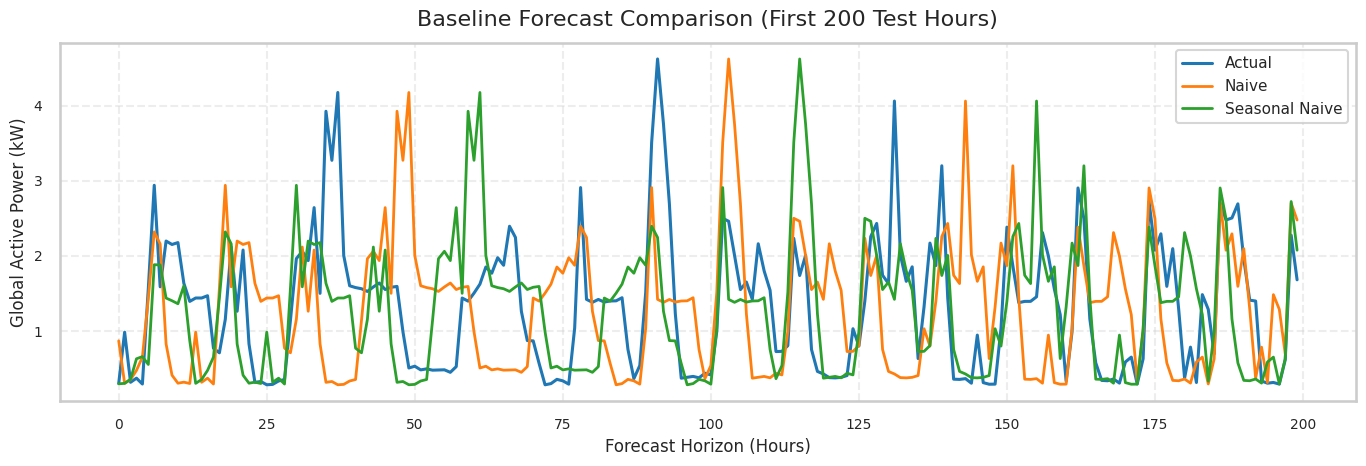

In [70]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(test[target].values[:200], label="Actual", linewidth=2.2, color=COLORS["primary"])
ax.plot(naive_pred.values[:200], label="Naive", linewidth=2, color=COLORS["secondary"])
ax.plot(seasonal_naive_pred.values[:200], label="Seasonal Naive", linewidth=2, color=COLORS["accent"])
ax.set_title("Baseline Forecast Comparison (First 200 Test Hours)", pad=12)
ax.set_xlabel("Forecast Horizon (Hours)")
ax.set_ylabel("Global Active Power (kW)")
ax.legend(frameon=True)
ax.grid(True, linestyle="--", alpha=0.35)
plt.tight_layout()
plt.show()

## 13. First Classical Model – SARIMA

**13.1 Check Stationarity**

In [33]:
from statsmodels.tsa.stattools import adfuller

adf_test = adfuller(train[target])
print("ADF Statistic:", adf_test[0])
print("p-value:", adf_test[1])

ADF Statistic: -12.600155226085274
p-value: 1.743360729893332e-23


**13.2 Fit SARIMA**

Since electricity has daily seasonality:

Seasonal period = 24

In [34]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(
    train[target],
    order=(1,0,1),
    seasonal_order=(1,0,1,24),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_model = model.fit()
print(sarima_model.summary())

                                     SARIMAX Results                                      
Dep. Variable:                Global_active_power   No. Observations:                27632
Model:             SARIMAX(1, 0, 1)x(1, 0, 1, 24)   Log Likelihood              -24211.169
Date:                            Fri, 27 Mar 2026   AIC                          48432.337
Time:                                    22:40:21   BIC                          48473.466
Sample:                                12-18-2006   HQIC                         48445.586
                                     - 02-12-2010                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6333      0.006    107.182      0.000       0.622       0.645
ma.L1         -0.0002      0.008   

**13.3 Forecast**

In [35]:
sarima_forecast = sarima_model.forecast(steps=len(test))

mae_s, rmse_s, smape_s = evaluate(test[target], sarima_forecast)

print("SARIMA Results:")
print("MAE:", mae_s)
print("RMSE:", rmse_s)
print("sMAPE:", smape_s)

SARIMA Results:
MAE: 0.5145223801492275
RMSE: 0.683324498376256
sMAPE: 51.333524228752424


After correcting for over-differencing, the SARIMA model improved substantially; however, it still did not outperform the naïve baseline. This suggests that short-term autocorrelation dominates the structure of the series. Further tuning or alternative modelling approaches such as machine learning may be required to outperform the persistence benchmark

### One-Step-Ahead vs Recursive Forecasting

Two evaluation settings are used for the machine learning models:

- **One-step-ahead prediction:** the model predicts the next observation using true historical values.
- **Recursive forecasting:** the model predicts future observations by feeding its own previous predictions back into the lag features.

This distinction is important because one-step-ahead evaluation is easier, whereas recursive forecasting is more realistic for operational forecasting.


## Tree Based Models.

Tree-based models are:

Robust to multicollinearity

Handle non-linearity

Strong for tabular time-series with lag features

Often outperform ARIMA

## 14. Prepare Feature Matrix.

We will:

Use all engineered features

Exclude the target variable

Keep chronological split

In [36]:
# ---- Build ML features safely on full series, then split ----
target = "Global_active_power"

full = df_model.copy()  # df_model already has lag + shifted rolling + calendar features

train_size = int(len(full) * 0.8)
train_ml = full.iloc[:train_size]
test_ml  = full.iloc[train_size:]

X_train = train_ml.drop(columns=[target])
y_train = train_ml[target]

X_test = test_ml.drop(columns=[target])
y_test = test_ml[target]

print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (27632, 26) Test: (6909, 26)


In [37]:
# Drop variables that would NOT be known in the future at forecast time
leaky_cols = [
    "Global_reactive_power", "Voltage", "Global_intensity",
    "Sub_metering_1", "Sub_metering_2", "Sub_metering_3"
]

X_train = X_train.drop(columns=leaky_cols, errors="ignore")
X_test  = X_test.drop(columns=leaky_cols, errors="ignore")

In [38]:
##---- 1. Ridge Regression.
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
ridge_pred = ridge.predict(X_test)

mae_r, rmse_r, smape_r = evaluate(y_test, ridge_pred)
print("Ridge -> MAE:", mae_r, "RMSE:", rmse_r, "sMAPE:", smape_r)

Ridge -> MAE: 0.3632171354434362 RMSE: 0.5144554713971429 sMAPE: 37.93452617658606


In [39]:
##---- 2. Random Forest Regression.
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

mae_rf, rmse_rf, smape_rf = evaluate(y_test, rf_pred)
print("RF -> MAE:", mae_rf, "RMSE:", rmse_rf, "sMAPE:", smape_rf)

RF -> MAE: 0.3359195447195629 RMSE: 0.47880943572462564 sMAPE: 34.2653709359502


In [40]:
mae_rf = mae_rf
rmse_rf = rmse_rf
smape_rf = smape_rf

In [41]:
##---- 3. XGBoost Regression.
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)

mae_xgb, rmse_xgb, smape_xgb = evaluate(y_test, xgb_pred)
print("XGBoost -> MAE:", mae_xgb, "RMSE:", rmse_xgb, "sMAPE:", smape_xgb)

XGBoost -> MAE: 0.3225735172733057 RMSE: 0.4620585406618157 sMAPE: 33.7327127196422


In [42]:
results = pd.DataFrame({
    "Model": ["Naive", "Seasonal Naive (24)", "SARIMA", "Ridge", "RandomForest", "XGBoost"],
    "MAE":   [mae_n, mae_sn, mae_s, mae_r, mae_rf, mae_xgb],
    "RMSE":  [rmse_n, rmse_sn, rmse_s, rmse_r, rmse_rf, rmse_xgb],
    "sMAPE(%)": [smape_n, smape_sn, smape_s, smape_r, smape_rf, smape_xgb]
})

results.sort_values("RMSE")

,Model,MAE,RMSE,sMAPE(%)
5,XGBoost,0.322574,0.462059,33.732713
4,RandomForest,0.335920,0.478809,34.265371
3,Ridge,0.363217,0.514455,37.934526
0,Naive,0.381306,0.589806,36.812807
2,SARIMA,0.514522,0.683324,51.333524
1,Seasonal Naive (24),0.525511,0.778032,49.165095


## Recursive Forecasting for XGBoost.

In [43]:
import pandas as pd
import numpy as np

target = "Global_active_power"

# Choose which features your ML model uses (must match training)
feature_cols = X_train.columns.tolist()

# Start history with training target values
history = y_train.copy()

recursive_preds = []

for ts in y_test.index:
    # Build a small series that includes history + a placeholder for the next timestamp
    temp = pd.concat([history, pd.Series([np.nan], index=[ts])])

    # Create features for this timestamp using ONLY past values
    row = {}
    row["hour"] = ts.hour
    row["dayofweek"] = ts.dayofweek
    row["month"] = ts.month
    row["is_weekend"] = int(ts.dayofweek >= 5)

    # Lags
    for lag in [1, 2, 3, 6, 12, 24]:
        row[f"{target}_lag_{lag}"] = temp.shift(lag).loc[ts]

    # Rolling (past-only)
    for w in [3, 6, 12, 24]:
        row[f"{target}_roll_mean_{w}"] = temp.rolling(w).mean().shift(1).loc[ts]
        row[f"{target}_roll_std_{w}"]  = temp.rolling(w).std().shift(1).loc[ts]

    X_row = pd.DataFrame([row], index=[ts])

    # Keep only the columns the model expects
    X_row = X_row.reindex(columns=feature_cols)

    # Predict
    yhat = xgb_model.predict(X_row)[0]
    recursive_preds.append(yhat)

    # Append prediction to history for next steps
    history = pd.concat([history, pd.Series([yhat], index=[ts])])

recursive_preds = pd.Series(recursive_preds, index=y_test.index)

mae_rec, rmse_rec, smape_rec = evaluate(y_test, recursive_preds)

print("Recursive XGBoost Results:")
print("MAE:", mae_rec)
print("RMSE:", rmse_rec)
print("sMAPE:", smape_rec)

Recursive XGBoost Results:
MAE: 0.519144612213337
RMSE: 0.6899982218783018
sMAPE: 50.94208587879822


## Recursive Forecasting for RandomForest.

In [44]:
import pandas as pd
import numpy as np

target = "Global_active_power"

# Choose which features your ML model uses (must match training)
feature_cols = X_train.columns.tolist()

# Start history with training target values
history = y_train.copy()

recursive_preds = []

for ts in y_test.index:
    # Build a small series that includes history + a placeholder for the next timestamp
    temp = pd.concat([history, pd.Series([np.nan], index=[ts])])

    # Create features for this timestamp using ONLY past values
    row = {}
    row["hour"] = ts.hour
    row["dayofweek"] = ts.dayofweek
    row["month"] = ts.month
    row["is_weekend"] = int(ts.dayofweek >= 5)

    # Lags
    for lag in [1, 2, 3, 6, 12, 24]:
        row[f"{target}_lag_{lag}"] = temp.shift(lag).loc[ts]

    # Rolling (past-only)
    for w in [3, 6, 12, 24]:
        row[f"{target}_roll_mean_{w}"] = temp.rolling(w).mean().shift(1).loc[ts]
        row[f"{target}_roll_std_{w}"]  = temp.rolling(w).std().shift(1).loc[ts]

    X_row = pd.DataFrame([row], index=[ts])

    # Keep only the columns the model expects
    X_row = X_row.reindex(columns=feature_cols)

    # Predict
    yhat = rf.predict(X_row)[0]
    recursive_preds.append(yhat)

    # Append prediction to history for next steps
    history = pd.concat([history, pd.Series([yhat], index=[ts])])

recursive_preds = pd.Series(recursive_preds, index=y_test.index)

mae_rec_rf, rmse_rec_rf, smape_rec_rf = evaluate(y_test, recursive_preds)

print("Recursive RandomForest Results:")
print("MAE:", mae_rec_rf)
print("RMSE:", rmse_rec_rf)
print("sMAPE:", smape_rec_rf)

Recursive RandomForest Results:
MAE: 0.574132747253384
RMSE: 0.7072369424455714
sMAPE: 58.42628894950739


In [45]:
mae_rf_rec = mae_rec_rf

rmse_rf_rec = rmse_rec_rf
smape_rf_rec = smape_rec_rf



### Helper Metrics.

In [46]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error

def smape(y_true, y_pred):
    denom = (np.abs(y_true) + np.abs(y_pred)) / 2.0
    denom = np.where(denom == 0, 1e-8, denom)
    return np.mean(np.abs(y_true - y_pred) / denom) * 100

def evaluate(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    sm = smape(y_true, y_pred)
    return mae, rmse, sm

## 15. Walk-Forward Validation

To test whether model performance is stable across different time periods, a three-fold walk-forward validation is included.  
An expanding training window is used in each fold, and the model is evaluated on the next unseen block of observations.

Due to computational cost, walk-forward validation is applied to representative models:
- Naive baseline
- SARIMA
- Recursive XGBoost

### Walk-forward for Naive.

In [47]:
y_full = df_interp.resample("H").mean()["Global_active_power"].dropna()

/tmp/ipykernel_10121/1179531669.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  y_full = df_interp.resample("H").mean()["Global_active_power"].dropna()


In [48]:
fold_results_naive = []

initial_train_size = int(len(y_full) * 0.6)
test_block_size = int(len(y_full) * 0.1)

start_train = initial_train_size

for fold in range(3):
    train_end = start_train + fold * test_block_size
    test_end = train_end + test_block_size

    if test_end > len(y_full):
        break

    y_train_wf = y_full.iloc[:train_end]
    y_test_wf = y_full.iloc[train_end:test_end]

    naive_pred = y_test_wf.shift(1)
    naive_pred.iloc[0] = y_train_wf.iloc[-1]

    mae, rmse, sm = evaluate(y_test_wf, naive_pred)

    fold_results_naive.append({
        "Fold": fold + 1,
        "Model": "Naive",
        "MAE": mae,
        "RMSE": rmse,
        "sMAPE": sm
    })

wf_naive_df = pd.DataFrame(fold_results_naive)
wf_naive_df

,Fold,Model,MAE,RMSE,sMAPE
0,1,Naive,0.341509,0.545613,37.953280
1,2,Naive,0.480516,0.709505,37.844104
2,3,Naive,0.401899,0.614024,36.878581


### Walk-forward for SARIMA

In [49]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

fold_results_sarima = []

for fold in range(3):
    train_end = initial_train_size + fold * test_block_size
    test_end = train_end + test_block_size

    if test_end > len(y_full):
        break

    y_train_wf = y_full.iloc[:train_end]
    y_test_wf = y_full.iloc[train_end:test_end]

    sarima_model_wf = SARIMAX(
        y_train_wf,
        order=(1,0,1),
        seasonal_order=(1,0,1,24),
        enforce_stationarity=False,
        enforce_invertibility=False
    ).fit(disp=False)

    sarima_pred_wf = sarima_model_wf.forecast(steps=len(y_test_wf))

    mae, rmse, sm = evaluate(y_test_wf, sarima_pred_wf)

    fold_results_sarima.append({
        "Fold": fold + 1,
        "Model": "SARIMA",
        "MAE": mae,
        "RMSE": rmse,
        "sMAPE": sm
    })

wf_sarima_df = pd.DataFrame(fold_results_sarima)
wf_sarima_df

,Fold,Model,MAE,RMSE,sMAPE
0,1,SARIMA,0.438243,0.579112,52.803069
1,2,SARIMA,0.704083,0.998038,58.510837
2,3,SARIMA,0.508027,0.674905,47.445159


### Walk-forward for Recursive XGBoost

This uses your already-trained approach, but retrains inside each fold.

In [50]:
from xgboost import XGBRegressor

def make_features_for_wf(series, target_col="Global_active_power"):
    df = pd.DataFrame({target_col: series})
    df["hour"] = df.index.hour
    df["dayofweek"] = df.index.dayofweek
    df["month"] = df.index.month
    df["is_weekend"] = (df["dayofweek"] >= 5).astype(int)

    for lag in [1, 2, 3, 6, 12, 24]:
        df[f"{target_col}_lag_{lag}"] = df[target_col].shift(lag)

    for w in [3, 6, 12, 24]:
        df[f"{target_col}_roll_mean_{w}"] = df[target_col].rolling(w).mean().shift(1)
        df[f"{target_col}_roll_std_{w}"] = df[target_col].rolling(w).std().shift(1)

    return df.dropna()

In [51]:
fold_results_xgb_rec = []

for fold in range(3):
    train_end = initial_train_size + fold * test_block_size
    test_end = train_end + test_block_size

    if test_end > len(y_full):
        break

    y_train_wf = y_full.iloc[:train_end]
    y_test_wf = y_full.iloc[train_end:test_end]

    full_series = pd.concat([y_train_wf, y_test_wf])
    feat_df = make_features_for_wf(full_series)

    train_feat = feat_df.loc[feat_df.index.intersection(y_train_wf.index)]
    test_feat = feat_df.loc[feat_df.index.intersection(y_test_wf.index)]

    X_train_wf = train_feat.drop(columns=["Global_active_power"])
    y_train_ml_wf = train_feat["Global_active_power"]

    X_test_wf = test_feat.drop(columns=["Global_active_power"])
    y_test_ml_wf = test_feat["Global_active_power"]

    xgb_wf = XGBRegressor(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )
    xgb_wf.fit(X_train_wf, y_train_ml_wf)

    # Recursive forecast
    history = y_train_wf.copy()
    recursive_preds = []

    for ts in y_test_ml_wf.index:
        temp = pd.concat([history, pd.Series([np.nan], index=[ts])])

        row = {
            "hour": ts.hour,
            "dayofweek": ts.dayofweek,
            "month": ts.month,
            "is_weekend": int(ts.dayofweek >= 5)
        }

        for lag in [1, 2, 3, 6, 12, 24]:
            row[f"Global_active_power_lag_{lag}"] = temp.shift(lag).loc[ts]

        for w in [3, 6, 12, 24]:
            row[f"Global_active_power_roll_mean_{w}"] = temp.rolling(w).mean().shift(1).loc[ts]
            row[f"Global_active_power_roll_std_{w}"] = temp.rolling(w).std().shift(1).loc[ts]

        X_row = pd.DataFrame([row], index=[ts])
        X_row = X_row.reindex(columns=X_train_wf.columns)

        yhat = xgb_wf.predict(X_row)[0]
        recursive_preds.append(yhat)

        history = pd.concat([history, pd.Series([yhat], index=[ts])])

    recursive_preds = pd.Series(recursive_preds, index=y_test_ml_wf.index)

    mae, rmse, sm = evaluate(y_test_ml_wf, recursive_preds)

    fold_results_xgb_rec.append({
        "Fold": fold + 1,
        "Model": "Recursive XGBoost",
        "MAE": mae,
        "RMSE": rmse,
        "sMAPE": sm
    })

wf_xgb_df = pd.DataFrame(fold_results_xgb_rec)
wf_xgb_df

,Fold,Model,MAE,RMSE,sMAPE
0,1,Recursive XGBoost,0.511733,0.673847,56.693046
1,2,Recursive XGBoost,0.552680,0.760714,44.895741
2,3,Recursive XGBoost,0.493872,0.660592,46.958885


### Combined walk-forward summary.

In [52]:
wf_all = pd.concat([wf_naive_df, wf_sarima_df, wf_xgb_df], ignore_index=True)
wf_all

,Fold,Model,MAE,RMSE,sMAPE
0,1,Naive,0.341509,0.545613,37.953280
1,2,Naive,0.480516,0.709505,37.844104
2,3,Naive,0.401899,0.614024,36.878581
3,1,SARIMA,0.438243,0.579112,52.803069
4,2,SARIMA,0.704083,0.998038,58.510837
5,3,SARIMA,0.508027,0.674905,47.445159
6,1,Recursive XGBoost,0.511733,0.673847,56.693046
7,2,Recursive XGBoost,0.552680,0.760714,44.895741
8,3,Recursive XGBoost,0.493872,0.660592,46.958885


In [53]:
wf_summary = wf_all.groupby("Model")[["MAE", "RMSE", "sMAPE"]].mean().reset_index()
wf_summary.sort_values("RMSE")

,Model,MAE,RMSE,sMAPE
0,Naive,0.407975,0.623047,37.558655
1,Recursive XGBoost,0.519429,0.698384,49.515891
2,SARIMA,0.550118,0.750685,52.919688


### Model Comparison.

In [54]:
# Main Results Table.

final_results = pd.DataFrame({
    "Model": [
        "Naive",
        "Seasonal Naive",
        "SARIMA",
        "Ridge (1-step)",
        "Random Forest (1-step)",
        "XGBoost (1-step)",
        "Random Forest (recursive)",
        "XGBoost (recursive)"
    ],
    "MAE": [
        mae_n, mae_sn, mae_s,
        mae_r, mae_rf, mae_xgb,
        mae_rf_rec, mae_rec
    ],
    "RMSE": [
        rmse_n, rmse_sn, rmse_s,
        rmse_r, rmse_rf, rmse_xgb,
        rmse_rf_rec, rmse_rec
    ],
    "sMAPE": [
        smape_n, smape_sn, smape_s,
        smape_r, smape_rf, smape_xgb,
        smape_rf_rec, smape_rec
    ],
    "Evaluation_Type": [
        "Baseline",
        "Baseline",
        "Classical",
        "1-step ML",
        "1-step ML",
        "1-step ML",
        "Recursive ML",
        "Recursive ML"
    ]
})

final_results.sort_values("RMSE")

,Model,MAE,RMSE,sMAPE,Evaluation_Type
5,XGBoost (1-step),0.322574,0.462059,33.732713,1-step ML
4,Random Forest (1-step),0.335920,0.478809,34.265371,1-step ML
3,Ridge (1-step),0.363217,0.514455,37.934526,1-step ML
0,Naive,0.381306,0.589806,36.812807,Baseline
2,SARIMA,0.514522,0.683324,51.333524,Classical
7,XGBoost (recursive),0.519145,0.689998,50.942086,Recursive ML
6,Random Forest (recursive),0.574133,0.707237,58.426289,Recursive ML
1,Seasonal Naive,0.525511,0.778032,49.165095,Baseline


### Best model by metric.

In [55]:
best_rmse = final_results.loc[final_results["RMSE"].idxmin()]
best_mae = final_results.loc[final_results["MAE"].idxmin()]
best_smape = final_results.loc[final_results["sMAPE"].idxmin()]

print("Best by RMSE:")
print(best_rmse)
print("\nBest by MAE:")
print(best_mae)
print("\nBest by sMAPE:")
print(best_smape)

Best by RMSE:
Model              XGBoost (1-step)
MAE                        0.322574
RMSE                       0.462059
sMAPE                     33.732713
Evaluation_Type           1-step ML
Name: 5, dtype: object

Best by MAE:
Model              XGBoost (1-step)
MAE                        0.322574
RMSE                       0.462059
sMAPE                     33.732713
Evaluation_Type           1-step ML
Name: 5, dtype: object

Best by sMAPE:
Model              XGBoost (1-step)
MAE                        0.322574
RMSE                       0.462059
sMAPE                     33.732713
Evaluation_Type           1-step ML
Name: 5, dtype: object


### Visual comparison.

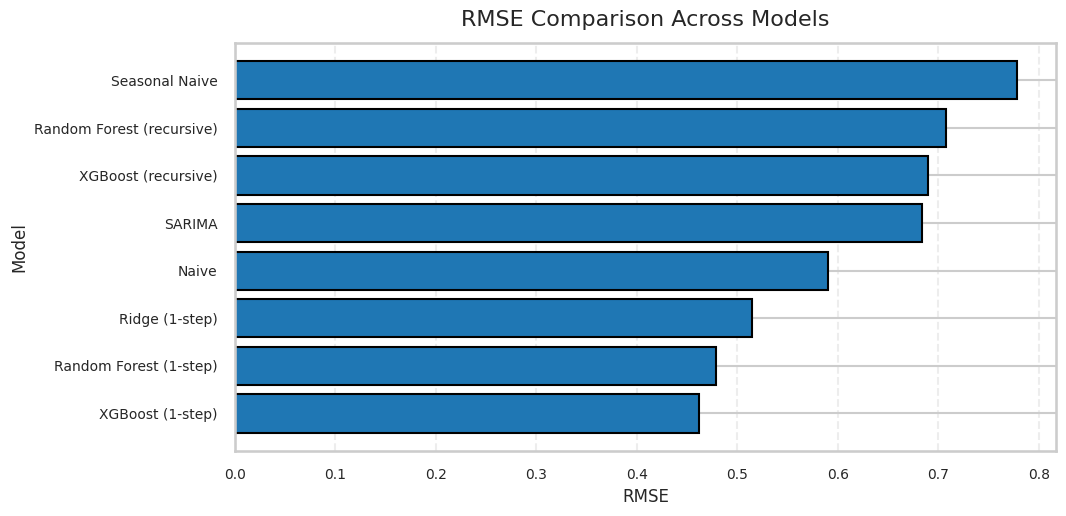

In [71]:
rmse_sorted = final_results.sort_values("RMSE")
fig, ax = plt.subplots(figsize=(11, 5.5))
ax.barh(rmse_sorted["Model"], rmse_sorted["RMSE"], color=COLORS["primary"], edgecolor="black")
ax.set_title("RMSE Comparison Across Models", pad=12)
ax.set_xlabel("RMSE")
ax.set_ylabel("Model")
ax.grid(axis="x", linestyle="--", alpha=0.35)
plt.tight_layout()
plt.show()

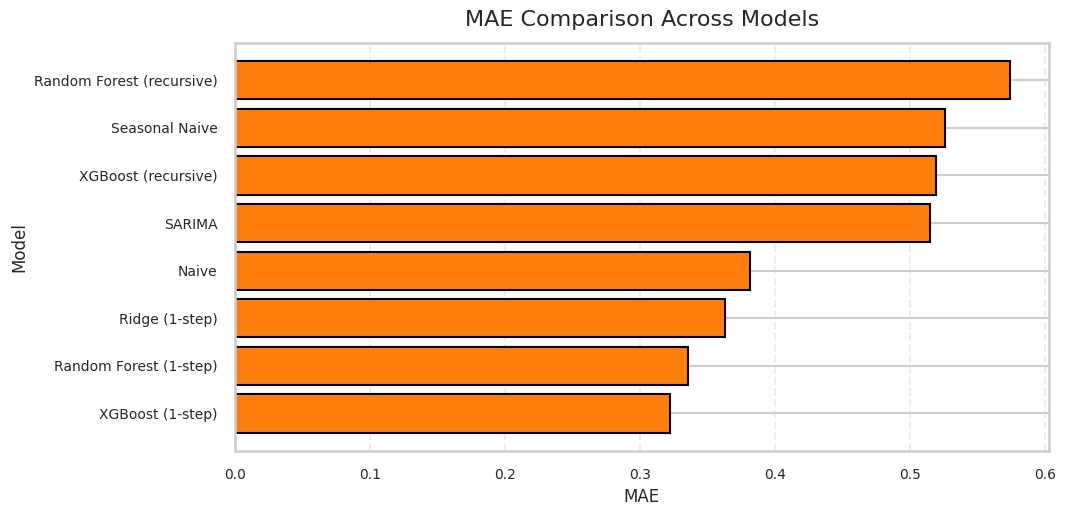

In [72]:
mae_sorted = final_results.sort_values("MAE")
fig, ax = plt.subplots(figsize=(11, 5.5))
ax.barh(mae_sorted["Model"], mae_sorted["MAE"], color=COLORS["secondary"], edgecolor="black")
ax.set_title("MAE Comparison Across Models", pad=12)
ax.set_xlabel("MAE")
ax.set_ylabel("Model")
ax.grid(axis="x", linestyle="--", alpha=0.35)
plt.tight_layout()
plt.show()

## 17. Error Analysis

Beyond aggregate metrics such as MAE and RMSE, residual analysis helps assess:
- whether errors are centred near zero,
- whether the model misses large peaks,
- and whether there are systematic over- or under-prediction patterns.

In [58]:
# Residuals

residuals_naive = y_test - naive_pred
residuals_sarima = y_test - sarima_forecast
common_index = y_test.index.intersection(recursive_preds.index)
residuals_xgb_rec = y_test.loc[common_index] - recursive_preds.loc[common_index]

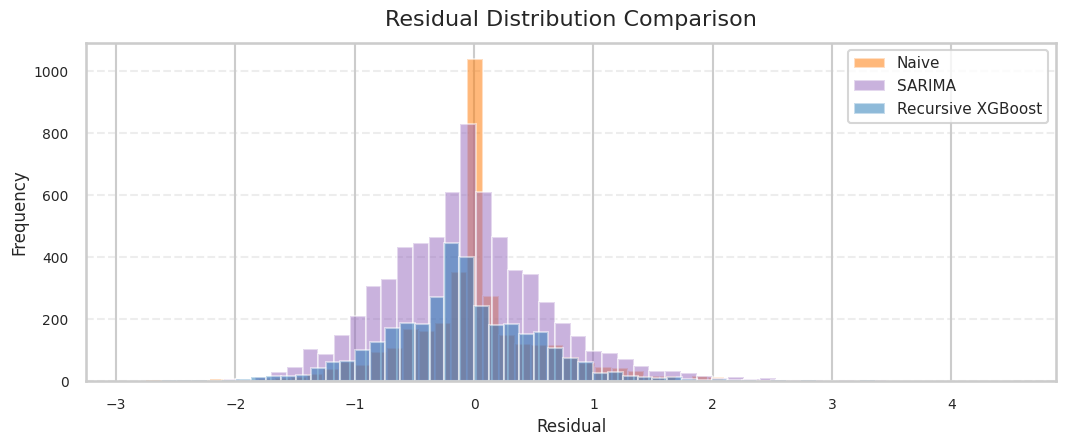

In [73]:
# Residual Histogram.
fig, ax = plt.subplots(figsize=(11, 4.8))
ax.hist(residuals_naive, bins=50, alpha=0.55, label="Naive", color=COLORS["secondary"])
ax.hist(residuals_sarima, bins=50, alpha=0.50, label="SARIMA", color=COLORS["purple"])
ax.hist(residuals_xgb_rec, bins=50, alpha=0.50, label="Recursive XGBoost", color=COLORS["primary"])
ax.set_title("Residual Distribution Comparison", pad=12)
ax.set_xlabel("Residual")
ax.set_ylabel("Frequency")
ax.legend(frameon=True)
ax.grid(axis="y", linestyle="--", alpha=0.35)
plt.tight_layout()
plt.show()

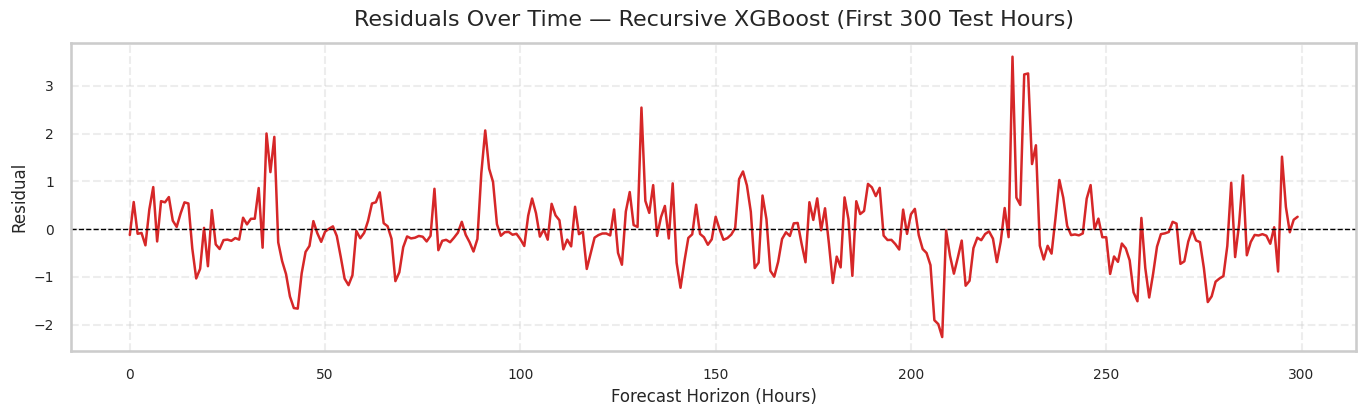

In [74]:
# Residuals over time.

fig, ax = plt.subplots(figsize=(14, 4.5))
ax.plot(residuals_xgb_rec.iloc[:300].values, color=COLORS["danger"], linewidth=1.8)
ax.axhline(0, color="black", linestyle="--", linewidth=1)
ax.set_title("Residuals Over Time — Recursive XGBoost (First 300 Test Hours)", pad=12)
ax.set_xlabel("Forecast Horizon (Hours)")
ax.set_ylabel("Residual")
ax.grid(True, linestyle="--", alpha=0.35)
plt.tight_layout()
plt.show()

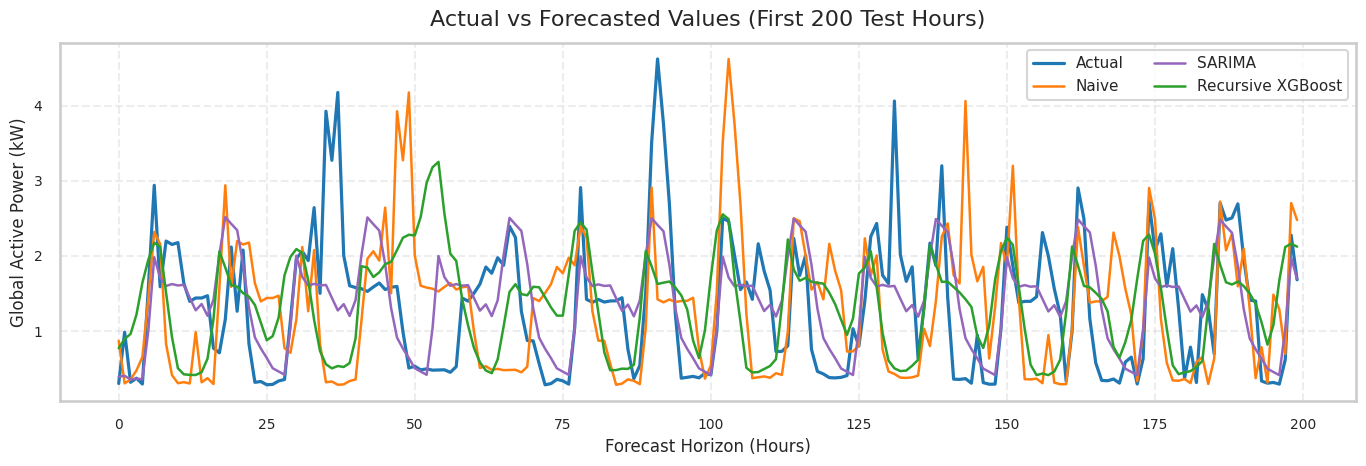

In [75]:
# Actual vs predicted plot.

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(y_test.iloc[:200].values, label="Actual", linewidth=2.3, color=COLORS["primary"])
ax.plot(naive_pred.iloc[:200].values, label="Naive", linewidth=1.8, color=COLORS["secondary"])
ax.plot(sarima_forecast.iloc[:200].values, label="SARIMA", linewidth=1.8, color=COLORS["purple"])
ax.plot(recursive_preds.iloc[:200].values, label="Recursive XGBoost", linewidth=1.8, color=COLORS["accent"])
ax.set_title("Actual vs Forecasted Values (First 200 Test Hours)", pad=12)
ax.set_xlabel("Forecast Horizon (Hours)")
ax.set_ylabel("Global Active Power (kW)")
ax.legend(frameon=True, ncol=2)
ax.grid(True, linestyle="--", alpha=0.35)
plt.tight_layout()
plt.show()

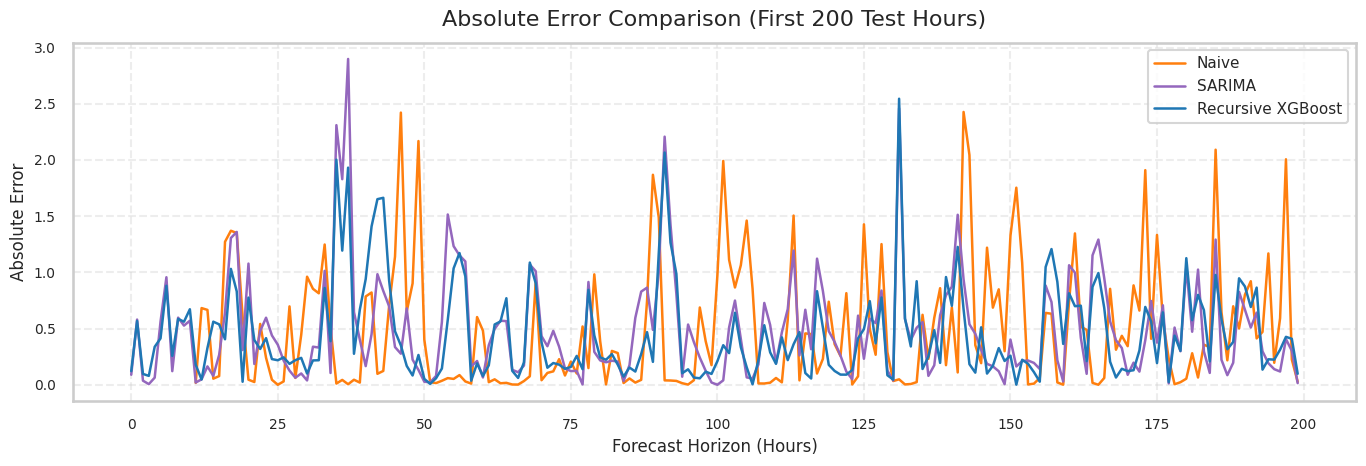

In [76]:
# Absolute error comparison.

abs_err_naive = np.abs(y_test - naive_pred)
abs_err_sarima = np.abs(y_test - sarima_forecast)

common_index = y_test.index.intersection(recursive_preds.index)
abs_err_xgb = np.abs(y_test.loc[common_index] - recursive_preds.loc[common_index])

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(abs_err_naive.iloc[:200].values, label="Naive", linewidth=1.8, color=COLORS["secondary"])
ax.plot(abs_err_sarima.iloc[:200].values, label="SARIMA", linewidth=1.8, color=COLORS["purple"])
ax.plot(abs_err_xgb.iloc[:200].values, label="Recursive XGBoost", linewidth=1.8, color=COLORS["primary"])
ax.set_title("Absolute Error Comparison (First 200 Test Hours)", pad=12)
ax.set_xlabel("Forecast Horizon (Hours)")
ax.set_ylabel("Absolute Error")
ax.legend(frameon=True)
ax.grid(True, linestyle="--", alpha=0.35)
plt.tight_layout()
plt.show()

## 🔚 Final Conclusion

This project explored the problem of **household electricity consumption forecasting** using both classical time-series models and modern machine learning techniques. The primary objective was to build a complete and realistic forecasting pipeline, starting from raw high-frequency data and progressing through preprocessing, feature engineering, modelling, and evaluation.

⚡ The dataset, consisting of minute-level electricity measurements from a single household, exhibited strong **short-term autocorrelation** and clear **daily usage patterns**. These characteristics reflect consistent human behaviour, such as routine activities during specific hours of the day. After identifying a small proportion of missing values (~1.25%), **time-based interpolation** was applied to preserve temporal continuity without introducing artificial distortions.

📊 To improve computational efficiency and reduce noise, the data was resampled from minute-level to **hourly averages**, resulting in a more manageable and structured dataset. Feature engineering played a crucial role in the modelling process, where **lag features**, **rolling statistics**, and **calendar-based variables** (such as hour of day and day of week) were created to capture both short-term dependencies and recurring seasonal patterns.

📈 Baseline models provided important reference points. The **naïve persistence model** performed strongly, highlighting that electricity consumption at a given time is highly dependent on its immediate past value. The **seasonal naïve model**, based on daily repetition, was less effective, indicating that short-term dynamics are more dominant than longer seasonal cycles in this dataset.

🔍 The **SARIMA model** was implemented to capture both temporal dependencies and daily seasonality. While it produced stable and interpretable results, it did not significantly outperform the naïve benchmark, reinforcing the idea that the dataset is highly persistence-driven.

🤖 Machine learning models, including **Ridge Regression, Random Forest, and XGBoost**, were then applied using engineered features. Under **one-step-ahead evaluation**, XGBoost achieved the best performance, demonstrating strong predictive capability when accurate historical values are available. However, this evaluation setup assumes perfect knowledge of past observations and does not fully reflect real-world forecasting conditions.

🔁 To address this, **recursive forecasting** was implemented, where model predictions are iteratively fed back as inputs for future predictions. Under this more realistic scenario, the performance of machine learning models decreased and became comparable to SARIMA. Importantly, the naïve model remained highly competitive, further confirming the strong persistence behaviour of the dataset.

📉 Additional evaluation through residual analysis and model comparison highlighted that:
- advanced models capture patterns effectively,
- but error accumulation in recursive forecasting reduces their advantage,
- and simple models remain surprisingly robust.

🎯 Overall, the project demonstrates that:
- electricity consumption forecasting is heavily influenced by **recent past behaviour**,
- **evaluation methodology** (one-step vs recursive) significantly affects model performance,
- and **simple baseline models** should not be underestimated.

🚀 In conclusion, while **XGBoost performed best under one-step-ahead prediction**, realistic forecasting conditions revealed that its performance aligns closely with classical models like SARIMA, and the naïve persistence model remains a strong benchmark. This highlights that, for this dataset, forecasting is dominated by short-term dependency, making substantial improvements over simple methods inherently challenging.

---

✨ This project successfully delivers a complete forecasting pipeline and provides meaningful insights into the strengths and limitations of different modelling approaches in real-world electricity consumption data.